Notatki:


CHEMBL2147 - łatwiejszy i lepszy od CHEMBL203 bo w 203 trzeba meic wieksza wiedze doemnowa aby dobrze poczyscic dataset

Do zrobienia:
wytrenowac model mlp scaffolda/random
wytrenowac siec grafowa
gnn scaffold i random

zestaw danych ok 10K - ograniczyc wzgledem białka 

najpierw wziac najlepszy podzbior danych - takich ktore wiemy ze sa najlepsze

zbudwac model na tych danych i doprowadzic do momentu gdy bedzie overfitting - wtedy bedzie wiadomo ze architektura jest ok ale problemy sa ze wzgledu na dane

----------------------------------------------------------------------------------------------


Na co zwracac uwage podczas trenowani

Scaffold - dzieli czasteczki na zestawy gdzie testowany jest na czasteczkach ktorych w ogole wczesniej model nie widzial

Moze byc tak ze model bedzie sie slabo uczyc a ale nie osiagnie najleposzego wyniku przez wartosci inicjalizujace wag z jakimi model wystrtowal lub przez dane jakie dalismy modelowi

"Martwe neurony" - przeczytac co to jest bo moze byc problemem

Jak monitorowac problem wygaszajacych sie neuronow?? -  przy pierwszych 5 epokach monitorowac czy jakies wagi nie zblizaja sie niebezpiecznie do zera

Patrzec czy mamy exploding lub vanishing gradient

Architektura GCN - sprawdzic co to jest 

Batch normalization - sprawdzic co to jest

wstrzykiwanie wartosci pierwotnych - sprawdzic

Dropout - pomijanie przy niektorych batchach czesci neuronow - poprawia uczenie

Przy epokach szczegolnie przy 5 pierwszysch printowac gradienty potem obserwowac loss function 

Learning rate moze byc za maly lub za duzy jak jest za duzy to najpierw loss function spada ale potem zaczyna oscylowac. Jak jest za maly to utknie na duzej wartosci loss funtion

Epsilon czyli cutoff - jesli loss function poprawia sie ale jest mniejsza niz podany epsilon to przerywamy trening bo wiemy ze kolejne trenowanie nie zwiekszy skutecznosci w znaczacy sposob

Na overfitting pomaga droput, smniejszenie wielkosci modelu, zwiekszenie zestawu treningowego, sprawdzenie czy zestaw treningowy nie jest za prosty wzgledem testowego

moga byd dwa poziomy learning rate - na poczatek wiekszy na pozniej mniejszy

MAD minimum average distance w grafie - sprawdzic to

Virtual node - sprawdzic sb

In [ ]:
#import torch
import sys
sys.path.append('..')

import numpy as np
import polars as pl
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from utils.utils import get_data_from_parquet, save_data_to_parquet

def smiles_to_fp(smiles, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        # Generowanie Morgan Fingerprint (promień 2 = ECFP4)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=n_bits)
        return np.array(fp)
    return None


/Users/a2251/Documents/IT_Dev/ujSem3/machineLearning/spark_airflow/chembl_env/lib/python3.12/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


# Importujemy dane

In [ ]:
df = get_data_from_parquet("../Chembl203_deduplicated10K.parquet")


Wczytywanie danych z pliku lokalnego: ../Chembl203_deduplicated10K.parquet


In [ ]:
df.head()

canonical_smiles,pchembl_value,mw,psa,hbd,hba,fingerprint,measurements_merged_count
str,f32,f32,f32,i32,i32,list[i64],u32
"""CCCCCCC(=O)ON[C@H](CS(C)(=O)=O…",6.96,695.210022,132.649994,2,10,"[0, 1, … 0]",1
"""CC(C)(C)N1CCC(N2C=C([C@@H](Nc3…",8.15,797.22998,103.75,4,11,"[0, 1, … 0]",1
"""COc1cc2ncc(C#N)c(Nc3ccc4c(cnn4…",6.89,531.619995,108.099998,2,8,"[0, 0, … 0]",1
"""N#Cc1cnc2c(Cl)cc(NCc3c[nH]nn3)…",6.0,428.26001,102.309998,3,6,"[0, 0, … 0]",1
"""Cc1cc(=O)n2nc(SCc3cccc(Cl)c3)n…",7.055,306.779999,63.049999,1,5,"[0, 0, … 1]",4


In [ ]:
df.describe()

statistic,canonical_smiles,pchembl_value,mw,psa,hbd,hba,fingerprint,measurements_merged_count
str,str,f64,f64,f64,f64,f64,f64,f64
"""count""","""10466""",10466.0,10466.0,10383.0,10383.0,10383.0,10466.0,10466.0
"""null_count""","""0""",0.0,0.0,83.0,83.0,83.0,0.0,0.0
"""mean""",null,6.925003,481.71167,95.147751,2.19243,7.005682,null,22.634244
"""std""",null,1.306664,119.964966,28.516798,1.155153,2.148697,null,853.325604
"""min""","""Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)c…",4.0,110.110001,3.88,0.0,0.0,null,1.0
"""25%""",null,5.96,401.450012,76.720001,1.0,6.0,null,1.0
"""50%""",null,7.01,480.579987,96.339996,2.0,7.0,null,1.0
"""75%""",null,7.92,554.719971,111.029999,3.0,8.0,null,4.0
"""max""","""c1nc(Nc2ccc3[nH]ccc3c2)c2sccc2…",11.0,1425.810059,272.980011,9.0,18.0,null,56977.0


In [ ]:
'''
df = df.with_columns([
    pl.col("canonical_smiles").map_elements(smiles_to_fp, return_dtype=pl.List(pl.Int64)).alias("fingerprint")
]).drop_nulls(subset=["fingerprint"])

df = df.with_columns(
    pl.col("pchembl_value").cast(pl.Int64, strict=False)
)
'''



# Konwersja do NumPy (X to macierz [N, 2048], y to [N, 1])
X = np.array(df["fingerprint"].to_list(), dtype=np.float32)
y = df["pchembl_value"].to_numpy().astype(np.float32).reshape(-1, 1)

In [ ]:
df.head()

canonical_smiles,pchembl_value,mw,psa,hbd,hba,fingerprint,measurements_merged_count
str,f32,f32,f32,i32,i32,list[i64],u32
"""CCCCCCC(=O)ON[C@H](CS(C)(=O)=O…",6.96,695.210022,132.649994,2,10,"[0, 1, … 0]",1
"""CC(C)(C)N1CCC(N2C=C([C@@H](Nc3…",8.15,797.22998,103.75,4,11,"[0, 1, … 0]",1
"""COc1cc2ncc(C#N)c(Nc3ccc4c(cnn4…",6.89,531.619995,108.099998,2,8,"[0, 0, … 0]",1
"""N#Cc1cnc2c(Cl)cc(NCc3c[nH]nn3)…",6.0,428.26001,102.309998,3,6,"[0, 0, … 0]",1
"""Cc1cc(=O)n2nc(SCc3cccc(Cl)c3)n…",7.055,306.779999,63.049999,1,5,"[0, 0, … 1]",4


In [ ]:
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    return None

# 1. Dodajemy kolumnę ze scaffoldem
df = df.with_columns([
    pl.col("canonical_smiles").map_elements(get_scaffold, return_dtype=pl.Utf8).alias("scaffold")
])

# 2. Pobieramy unikalne scaffoldy i mieszamy je
unique_scaffolds = df["scaffold"].unique().sample(fraction=1.0, shuffle=True)

# 3. Podział unikalnych scaffoldów (80/10/10)
n_scaffolds = len(unique_scaffolds)
train_scaffolds = unique_scaffolds[:int(0.8 * n_scaffolds)]
val_scaffolds = unique_scaffolds[int(0.8 * n_scaffolds):int(0.9 * n_scaffolds)]
test_scaffolds = unique_scaffolds[int(0.9 * n_scaffolds):]

# 4. Filtrowanie głównego DataFrame
train_df = df.filter(pl.col("scaffold").is_in(train_scaffolds))
val_df = df.filter(pl.col("scaffold").is_in(val_scaffolds))
test_df = df.filter(pl.col("scaffold").is_in(test_scaffolds))

/var/folders/xs/ng936c_15s1831tg8jwvbrqr0000gn/T/ipykernel_1037/189162480.py:24: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train_df = df.filter(pl.col("scaffold").is_in(train_scaffolds))
/var/folders/xs/ng936c_15s1831tg8jwvbrqr0000gn/T/ipykernel_1037/189162480.py:25: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  val_df = df.filter(pl.col("scaffold").is_in(val_scaffolds))
/var/folders/xs/ng936c_15s1831tg8jwvbrqr0000gn/T/ipykernel_1037/189162480.py:26: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/po

In [ ]:
import torch
import torch.nn as nn

class ChemMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(128, 1) # Regresja pIC50
        )
        
        # Inicjalizacja wag (He/Kaiming)
        for m in self.model:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.model(x)

# Hiperparametry
model = ChemMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [ ]:
# Sprawdź ile NaN/null jest w pchembl_value
print("Nulle w train_df:", train_df["pchembl_value"].null_count())
print("Typ kolumny:", train_df["pchembl_value"].dtype)

# Spróbuj skonwertować i sprawdź
vals = train_df["pchembl_value"].cast(pl.Float32, strict=False)
print("Nulle po konwersji:", vals.null_count())
print("Przykładowe wartości:", vals.head(10))


Nulle w train_df: 0
Typ kolumny: Float32
Nulle po konwersji: 0
Przykładowe wartości: shape: (10,)
Series: 'pchembl_value' [f32]
[
	6.96
	8.15
	6.89
	7.055
	4.25
	7.29
	5.21
	6.415
	7.265
	6.05
]


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class MoleculeDataset(Dataset):
    def __init__(self, df):
        # Konwersja kolumny 'fingerprint' (listy) na macierz NumPy, a potem na Tensor
        self.X = torch.tensor(np.array(df["fingerprint"].to_list()), dtype=torch.float32)
        # Konwersja pIC50 na Tensor
        self.y = torch.tensor(df["pchembl_value"].cast(pl.Float32).to_numpy(),dtype=torch.float32).reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Tworzymy instancje dla naszych zbiorów ze Scaffold Split
train_dataset = MoleculeDataset(train_df)
val_dataset = MoleculeDataset(val_df)
test_dataset = MoleculeDataset(test_df)

# Parametr batch_size (np. 64) decyduje ile cząsteczek model widzi naraz
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
import matplotlib.pyplot as plt

def train_model(model, train_loader, val_loader, epochs=50, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # np. 0.0001
    #optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Faza Treningu
        model.train()
        running_train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()        # zerowanie gradientów
            outputs = model(inputs)      # forward pass
            loss = criterion(outputs, targets)
            loss.backward()              # backward pass (obliczanie gradientów)
            optimizer.step()             # aktualizacja wag
            
            running_train_loss += loss.item() * inputs.size(0)
        
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Faza Walidacji (bez obliczania gradientów)
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_val_loss += loss.item() * inputs.size(0)
        
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        if (epoch+1) % 5 == 0:
            print(f"Epoka {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    return train_losses, val_losses

# Uruchomienie
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ChemMLP().to(device)
train_hist, val_hist = train_model(model, train_loader, val_loader, epochs=60, lr=0.005)

Epoka 5/60 | Train Loss: 1.3411 | Val Loss: 0.8872
Epoka 10/60 | Train Loss: 1.1204 | Val Loss: 0.8220
Epoka 15/60 | Train Loss: 0.9922 | Val Loss: 0.8739
Epoka 20/60 | Train Loss: 0.8945 | Val Loss: 0.7885
Epoka 25/60 | Train Loss: 0.8094 | Val Loss: 0.7835
Epoka 30/60 | Train Loss: 0.7162 | Val Loss: 0.9179
Epoka 35/60 | Train Loss: 0.6563 | Val Loss: 0.8667
Epoka 40/60 | Train Loss: 0.5973 | Val Loss: 0.7705
Epoka 45/60 | Train Loss: 0.5548 | Val Loss: 0.7280
Epoka 50/60 | Train Loss: 0.4978 | Val Loss: 0.7496
Epoka 55/60 | Train Loss: 0.4595 | Val Loss: 0.7489
Epoka 60/60 | Train Loss: 0.4161 | Val Loss: 0.7290


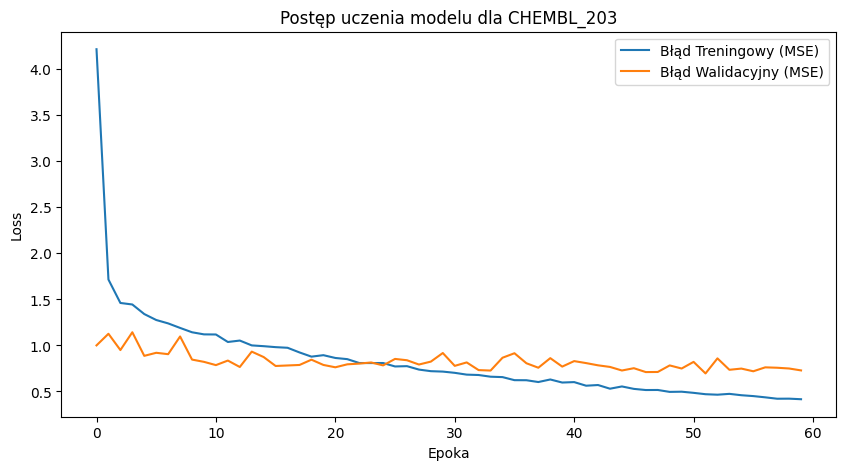

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_hist, label="Błąd Treningowy (MSE)")
plt.plot(val_hist, label="Błąd Walidacyjny (MSE)")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.title("Postęp uczenia modelu dla CHEMBL_203")
plt.legend()
plt.show()

In [ ]:
import polars as pl

# 1. Przetasuj cały, wyczyszczony dataset niczym talię kart (seed zapewnia odtwarzalność)
df_shuffled = df.sample(fraction=1.0, shuffle=True, seed=42)

# 2. Wylicz precyzyjne indeksy podziału (Klasyczne 80% / 10% / 10%)
total_rows = df_shuffled.shape[0]
train_idx = int(0.8 * total_rows)
val_idx = int(0.9 * total_rows)

# 3. Potnij DataFrame używając slice'ingu Polarsa
train_df = df_shuffled[:train_idx]
val_df = df_shuffled[train_idx:val_idx]
test_df = df_shuffled[val_idx:]

# Wyświetl raport upewiający
print("--- RANDOM SPLIT 80/10/10 ---")
print(f"Całkowita liczba molekuł: {total_rows}")
print(f"Rozmiar Train (do nauki): {train_df.shape[0]}")
print(f"Rozmiar Validation (do monitorowania loss): {val_df.shape[0]}")
print(f"Rozmiar Test (do całkowicie ostatecznego sprawdzianu, na razie nieużywany): {test_df.shape[0]}")


--- RANDOM SPLIT 80/10/10 ---
Całkowita liczba molekuł: 10466
Rozmiar Train (do nauki): 8372
Rozmiar Validation (do monitorowania loss): 1047
Rozmiar Test (do całkowicie ostatecznego sprawdzianu, na razie nieużywany): 1047



[RANDOM SPLIT] Zbiór podzielony tasowaniem na: 8372 / 1047 / 1047 wierszy.

Obliczenia PyTorch wędrują na urządzenie hardware: cpu
Epoka 05/60 | Train Loss (Z L2 i Dropout): 1.4585 | Val Loss: 0.7325
Epoka 10/60 | Train Loss (Z L2 i Dropout): 1.0660 | Val Loss: 0.6210
Epoka 15/60 | Train Loss (Z L2 i Dropout): 0.7685 | Val Loss: 0.5950
Epoka 20/60 | Train Loss (Z L2 i Dropout): 0.6140 | Val Loss: 0.6348
Epoka 25/60 | Train Loss (Z L2 i Dropout): 0.4908 | Val Loss: 0.5270
Epoka 30/60 | Train Loss (Z L2 i Dropout): 0.4313 | Val Loss: 0.5329
Epoka 35/60 | Train Loss (Z L2 i Dropout): 0.4073 | Val Loss: 0.5655
Epoka 40/60 | Train Loss (Z L2 i Dropout): 0.3734 | Val Loss: 0.5121
Epoka 45/60 | Train Loss (Z L2 i Dropout): 0.3758 | Val Loss: 0.5030
Epoka 50/60 | Train Loss (Z L2 i Dropout): 0.3574 | Val Loss: 0.5151
Epoka 55/60 | Train Loss (Z L2 i Dropout): 0.3585 | Val Loss: 0.5294
Epoka 60/60 | Train Loss (Z L2 i Dropout): 0.3619 | Val Loss: 0.5243


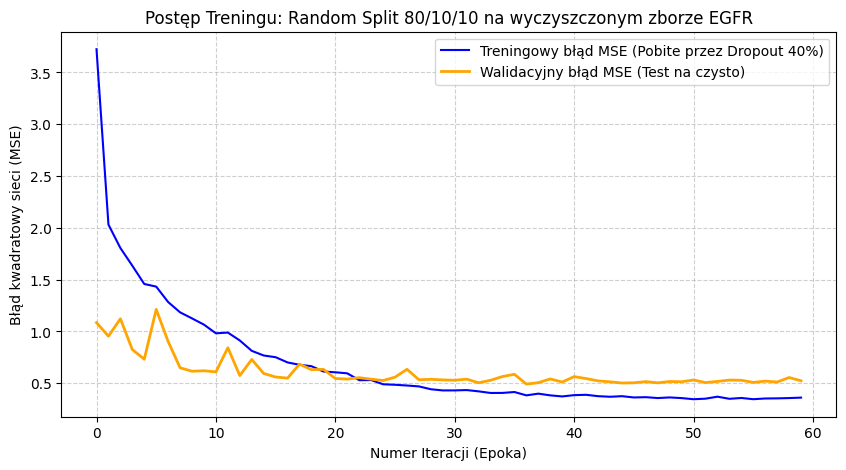

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# --- 1. RANDOM SPLIT (na wyczyszczonych danych) ---
# Zakładam że Twoje surowe wczytane i czyste dane w komórce wyżej zwą się `df` lub zaraz po odczycie
# df = pl.read_parquet("Chembl203_cleaned.parquet") 

# Jeśli generowałeś duplikaty za pomocą grupowania, nazwij to 'df_deduplicated' (pamiętaj tylko o upewnieniu się, która to nazwa pliku/zmiennej!)
data_to_split = df.sample(fraction=1.0, shuffle=True, seed=42)

total_rows = data_to_split.shape[0]
train_idx = int(0.8 * total_rows)
val_idx = int(0.9 * total_rows)

train_df = data_to_split[:train_idx]
val_df = data_to_split[train_idx:val_idx]
test_df = data_to_split[val_idx:]

print(f"\n[RANDOM SPLIT] Zbiór podzielony tasowaniem na: {train_df.shape[0]} / {val_df.shape[0]} / {test_df.shape[0]} wierszy.\n")

# --- 2. KLASA DATASETU I LADOWACZE DANYCH ---
class MoleculeDataset(Dataset):
    def __init__(self, data_frame):
        # Ze względu na odrzucenie wcześniej zepsutych wartości, rzutowanie powinno przejść gładko
        self.X = torch.tensor(np.array(data_frame["fingerprint"].to_list()), dtype=torch.float32)
        self.y = torch.tensor(data_frame["pchembl_value"].cast(pl.Float32).to_numpy(), dtype=torch.float32).reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(MoleculeDataset(train_df), batch_size=64, shuffle=True)
val_loader = DataLoader(MoleculeDataset(val_df), batch_size=64, shuffle=False)
test_loader = DataLoader(MoleculeDataset(test_df), batch_size=64, shuffle=False) # Do późniejszego testu jakości

# --- 3. DEFINICJA PĘTLI TRENINGOWEJ ---
def train_model(model, train_loader, val_loader, epochs=60, lr=0.001):
    # Dodajemy Weight Decay (regularyzację L2) 1e-4 do odpierania overfitingu!
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()
    
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * inputs.size(0)
        
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Faza Walidacji (Tryb Eval)
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_val_loss += loss.item() * inputs.size(0)
        
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        if (epoch+1) % 5 == 0:
            print(f"Epoka {epoch+1:02d}/{epochs} | Train Loss (Z L2 i Dropout): {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    return train_losses, val_losses

# --- 4. URUCHOMIENIE TRENINGU NA KARTACH GRAFICZNYCH / PROCESORZE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Obliczenia PyTorch wędrują na urządzenie hardware: {device}")

# Wywołujemy od nowa model (żeby "wyczyścił się" ze starych wag, nie zaczynamy treningu od nowa na poprzedniej bazie)
model_random = ChemMLP().to(device)

# Ruszamy! Idealny moment to zwykle okolice 50-60 przy tym setupie.
train_hist, val_hist = train_model(model_random, train_loader, val_loader, epochs=60, lr=0.005)

# --- 5. RYSUNEK EFEKTÓW ---
plt.figure(figsize=(10, 5))
plt.plot(train_hist, label="Treningowy błąd MSE (Pobite przez Dropout 40%)", color="blue")
plt.plot(val_hist, label="Walidacyjny błąd MSE (Test na czysto)", color="orange", linewidth=2)
plt.xlabel("Numer Iteracji (Epoka)")
plt.ylabel("Błąd kwadratowy sieci (MSE)")
plt.title("Postęp Treningu: Random Split 80/10/10 na wyczyszczonym zborze EGFR")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np
import torch

model_random.eval() # Wyłącza losowość sieci dla rzetelnej oceny!

all_true = []
all_pred = []

with torch.no_grad():
    for inputs, targets in val_loader: 
        inputs = inputs.to(device)
        outputs = model_random(inputs)
        
        all_pred.extend(outputs.detach().cpu().flatten().tolist())
        all_true.extend(targets.cpu().flatten().tolist())


all_true = np.array(all_true)
all_pred = np.array(all_pred)

# Wymóg biznesowy przypisujący Aktywność, jako punkt podziału
aktywnosc_prog = 6.0 

binary_true = (all_true >= aktywnosc_prog).astype(int)
# Jako próg predykcji do Accuracy też bierzemy 6.0
binary_pred = (all_pred >= aktywnosc_prog).astype(int)

# --- KLUCZOWE WYLICZENIA DO ZADANIA ---
try:
    # 1. ZADANIE: AUC (Wykorzystujemy ciągłe przewidywania, model porządkuje rosnąco)
    auc_value = roc_auc_score(binary_true, all_pred)
    
    # 2. DODATEK: Accuracy (Zgadywanie wprost - zgadł/nie zgadł progu 6.0)
    acc_value = accuracy_score(binary_true, binary_pred)

    print(f"==================================================")
    print(f" Wyniki w oparciu o próg Aktywności: pChEMBL >= {aktywnosc_prog}")
    print(f"==================================================")
    print(f" Prawdziwe ROC-AUC Score: {auc_value:.4f}  (Cel zadania: > 0.7)")
    print(f" Zwykła Dokładność (Accuracy): {acc_value:.4f}")
    
    if auc_value > 0.7:
         print(" Model zrealizował założenia.")
except ValueError:
    print("Error")


 Wyniki w oparciu o próg Aktywności: pChEMBL >= 6.0
 Prawdziwe ROC-AUC Score: 0.9309  (Cel zadania: > 0.7)
 Zwykła Dokładność (Accuracy): 0.8682
 Model zrealizował założenia.


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Obliczanie metryk regresji dla modelu
r2 = r2_score(all_true, all_pred)
mae = mean_absolute_error(all_true, all_pred)
rmse = np.sqrt(mean_squared_error(all_true, all_pred))

print("==================================================")
print(" Wyniki regresji (przewidywanie wartości pChEMBL)")
print("==================================================")
print(f" R^2 Score (Współczynnik determinacji): {r2:.4f}")
print(f" MAE (Średni błąd bezwzględny): {mae:.4f}")
print(f" RMSE (Pierwiastek błędu średniokwadratowego): {rmse:.4f}")
